In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from torchvision.datasets.folder import ImageFolder, default_loader, IMG_EXTENSIONS 
import torchvision.models as models
from PIL import Image
from models import ClassifieurMovie, ClassifieurResNet18, ClassifieurResNet34

from data_utils import ImageAndPathDataset

In [2]:
transform = transforms.Compose([transforms.Resize((224, 224)),
                                transforms.ToTensor()])
dataset = ImageAndPathDataset('./../MovieGenre/content/sorted_movie_posters_paligema', transform)

In [3]:
dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=4)

In [4]:
ds = ImageFolder('./../MovieGenre/content/sorted_movie_posters_paligema', transform=transform, loader=default_loader)

In [5]:
ds.find_classes('./../MovieGenre/content/sorted_movie_posters_paligema')

(['action',
  'animation',
  'comedy',
  'documentary',
  'drama',
  'fantasy',
  'horror',
  'romance',
  'science Fiction',
  'thriller'],
 {'action': 0,
  'animation': 1,
  'comedy': 2,
  'documentary': 3,
  'drama': 4,
  'fantasy': 5,
  'horror': 6,
  'romance': 7,
  'science Fiction': 8,
  'thriller': 9})

In [6]:
dt = DataLoader(ds, batch_size=4, shuffle=True, num_workers=4)

In [7]:
x, y = next(iter(dt))

In [8]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, confusion_matrix

categories = ['action', 'animation', 'comedy', 'documentary',
                'drama', 'fantasy', 'horror', 'romance',
                'science fiction', 'thriller']

#encoder = LabelEncoder()
#encoder.fit(categories)



In [9]:
model_path = 'weights/movie_net_mob_none.pth'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = models.mobilenet_v3_small(weights=None)
model.classifier = torch.nn.Linear(576, 10)


model = ClassifieurMovie()


# Load the model
model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu'), weights_only=True))
#model.eval()

model.to(device)


ClassifieurMovie(
  (model): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
            (activation): ReLU()
            (scale_activation): Hardsigmoid()
          )
          (2): C

In [10]:
# Confusion matrix
y_true = []
y_pred = []

for x, y in dt:
    x = x.to(device)
    y = y.to(device)
    y_true.extend(y.cpu().numpy())
    y_pred.extend(model(x).argmax(dim=1).cpu().numpy())

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=categories)


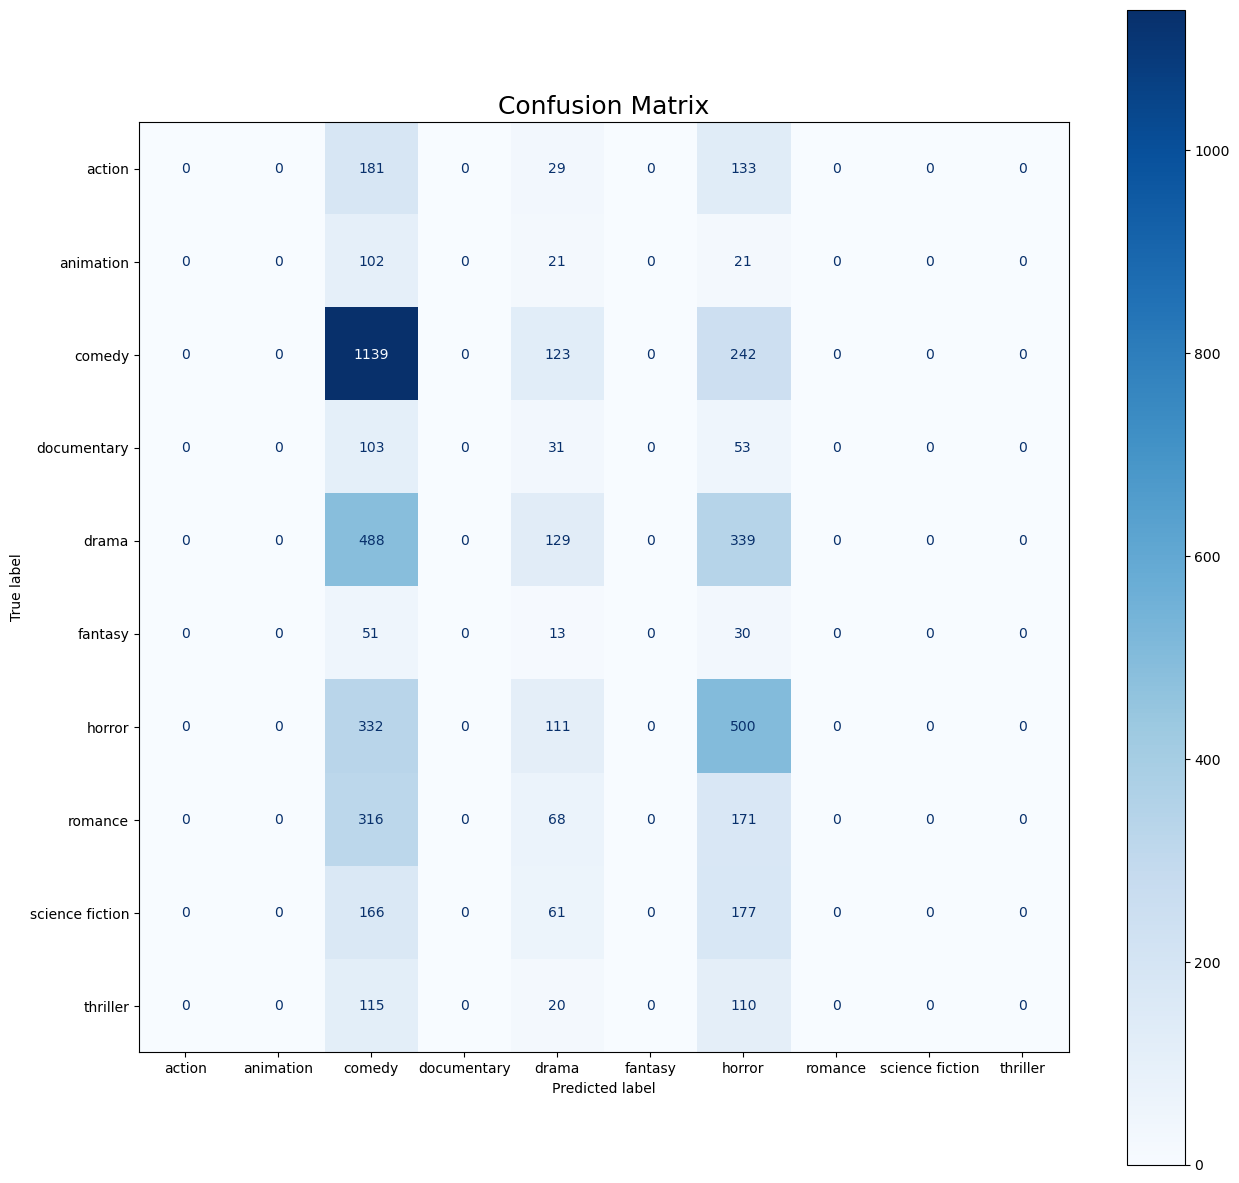

In [11]:
fig, ax = plt.subplots(figsize=(15, 15))  # définit une grande taille
disp.plot(cmap=plt.cm.Blues, values_format='d', ax=ax)  # utilise le grand axe
plt.title('Confusion Matrix', fontsize=18)  # optionnel : plus gros titre
plt.show()

## Testing the API

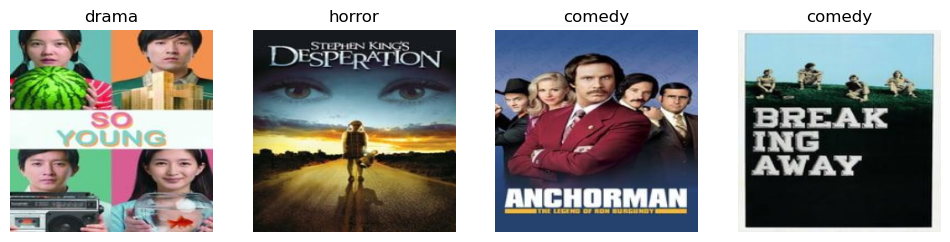

In [21]:
import matplotlib.pyplot as plt

x, y = next(iter(dt))

fig, ax = plt.subplots(1, 4, figsize=(12, 3))
for i in range(4):
    ax[i].imshow(x[i].permute(1, 2, 0))
    ax[i].set_title(categories[y[i].item()])
    ax[i].axis('off')

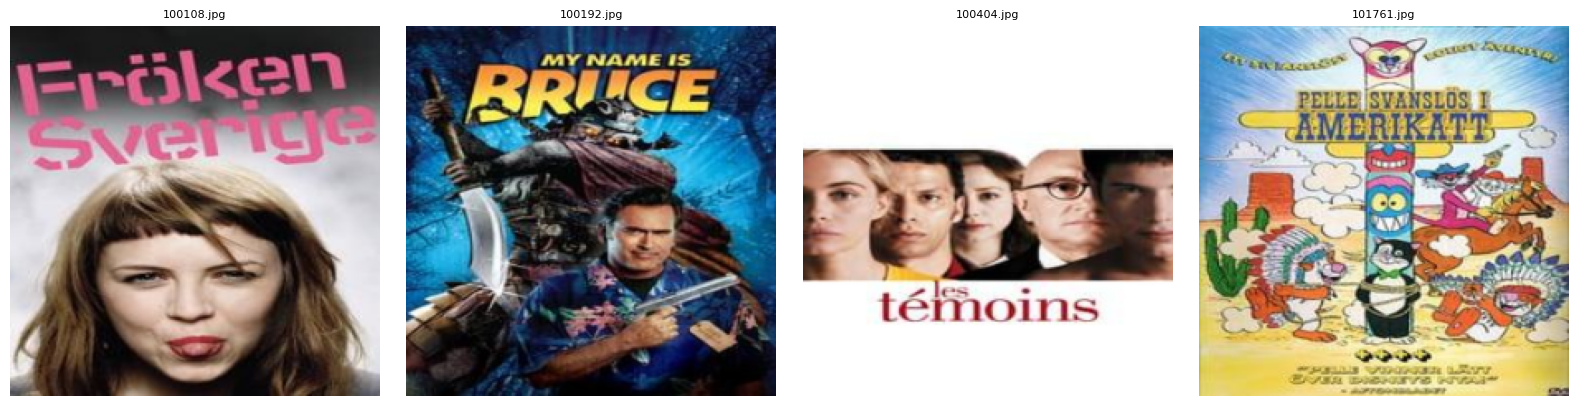

In [35]:
x, y = next(iter(dt))
fig, ax = plt.subplots(1, 4, figsize=(16, 4))

# Pour chaque image affichée
for i in range(4):
    ax[i].imshow(x[i].permute(1, 2, 0))
    
    # Récupérer l'index réel dans le dataset original (DataLoader shuffle=False sinon ce sera incorrect)
    img_path = dt.dataset.imgs[i][0]  # <- chemin de l'image
    ax[i].set_title(img_path.split("/")[-1], fontsize=8)  # ou juste afficher le nom de fichier
    ax[i].axis('off')

plt.tight_layout()
plt.show()


In [33]:
predicted_horror_images = []

with torch.no_grad():
    for x, y in dt:
        x = x.to(device)
        outputs = model(x)
        preds = torch.argmax(outputs, dim=1).cpu()
        print(preds)

        for i in range(len(preds)):
            if categories[preds[i].item()] == 0:
                # Récupérer le chemin si c'est une ImageFolder
                img_path = dt.dataset.imgs[i][0]
                predicted_horror_images.append((x[i].cpu(), img_path))

tensor([2, 2, 6, 4])
tensor([6, 2, 4, 2])
tensor([4, 6, 2, 2])
tensor([6, 2, 2, 6])
tensor([2, 2, 2, 6])
tensor([6, 2, 2, 4])
tensor([2, 4, 2, 6])
tensor([4, 2, 6, 2])
tensor([2, 6, 2, 6])
tensor([2, 6, 6, 2])
tensor([4, 6, 2, 6])
tensor([2, 6, 2, 4])
tensor([4, 6, 2, 2])
tensor([2, 6, 2, 6])
tensor([2, 2, 6, 2])
tensor([2, 2, 4, 6])
tensor([2, 6, 2, 2])
tensor([4, 2, 6, 2])
tensor([2, 2, 6, 2])
tensor([2, 4, 2, 6])
tensor([6, 2, 2, 6])
tensor([2, 2, 4, 6])
tensor([2, 2, 6, 2])
tensor([6, 2, 2, 2])
tensor([2, 6, 2, 2])
tensor([2, 4, 6, 2])
tensor([2, 6, 2, 2])
tensor([6, 2, 2, 6])
tensor([2, 6, 6, 2])
tensor([6, 4, 2, 2])
tensor([6, 4, 2, 2])
tensor([6, 2, 6, 2])
tensor([2, 2, 6, 2])
tensor([2, 4, 6, 2])
tensor([4, 2, 2, 6])
tensor([2, 6, 6, 2])
tensor([2, 6, 6, 4])
tensor([6, 2, 6, 2])
tensor([6, 6, 2, 2])
tensor([6, 2, 2, 2])
tensor([2, 4, 6, 2])
tensor([2, 4, 2, 6])
tensor([2, 6, 6, 2])
tensor([2, 2, 6, 4])
tensor([6, 2, 6, 2])
tensor([4, 2, 2, 6])
tensor([2, 6, 4, 2])
tensor([6, 2,

In [32]:
print(predicted_horror_images)

[]


In [42]:
#predire juste une image

with torch.no_grad():
    img, _ = dt.dataset[0]  # Récupérer la première image du dataset
    img = img.unsqueeze(0).to(device)  # Ajouter une dimension pour le batch
    output = model(img)
    print(output)
    print(output.max(1))
    print(output.max(1)[0])
    pred = torch.argmax(output, dim=1).item()
    print(pred)
    print(f"Predicted class: {categories[pred]}")

tensor([[-0.2418, -0.6960,  0.6183, -0.6506,  0.3541, -0.7676,  0.4469,  0.0537,
         -0.2417, -0.4031]], device='cuda:0')
torch.return_types.max(
values=tensor([0.6183], device='cuda:0'),
indices=tensor([2], device='cuda:0'))
tensor([0.6183], device='cuda:0')
2
Predicted class: comedy


In [54]:
#Predire plusieurs images et afficher leur path

x, y = next(iter(dt))

with torch.no_grad():
    x = x.to(device)
    outputs = model(x)
    preds = torch.argmax(outputs, dim=1).cpu()

    for i in range(len(preds)):
        print(f"Image {i}: {categories[preds[i].item()]} - Path: {dt.dataset.imgs[i][0]}")


Image 0: comedy - Path: ./../MovieGenre/content/sorted_movie_posters_paligema/action/100108.jpg
Image 1: horror - Path: ./../MovieGenre/content/sorted_movie_posters_paligema/action/100192.jpg
Image 2: horror - Path: ./../MovieGenre/content/sorted_movie_posters_paligema/action/100404.jpg
Image 3: comedy - Path: ./../MovieGenre/content/sorted_movie_posters_paligema/action/101761.jpg


In [52]:
genres_dict = {0 : 'action',1 :'animation', 2 : 'comedy', 3 : 'documentary', 
                4 : 'drama', 5 : 'fantasy', 6 : 'horror', 7 : 'romance', 
                8 : 'science Fiction',9 : 'thriller'}

In [36]:
import requests
import io

for i in range(4):
    image, label = x[i], y[i]
    label = genres_dict[label.item()]
    to_PIL = transforms.ToPILImage()
    image = to_PIL(image)
    img_binary = io.BytesIO()
    image.save(img_binary, format='PNG')
    #Send request to the API
    response = requests.post("http://127.0.0.1:5000/predict", data=img_binary.getvalue())
    print("Predicted Label:", response.json()["prediction"], "True Label:", label)

Predicted Label: action True Label: comedy
Predicted Label: action True Label: horror
Predicted Label: action True Label: drama
Predicted Label: action True Label: animation


In [15]:
image, label = x[0], y[0]

to_PIL = transforms.ToPILImage()
img_pil = to_PIL(image)
img_pil.show()
img_binary = io.BytesIO()
img_pil.save(img_binary, format='PNG')

imp_pil = Image.open(io.BytesIO(img_binary.getvalue()))